In [1]:
import pymc as pm, polars as pl, arviz as az

from utils import extract_quantile_columns, standardize_columns, plot_trace

In [2]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/NWOGrants.csv", separator=";").with_columns(
    gender=pl.col("gender").cast(pl.Categorical),
    discipline=pl.col("discipline").cast(pl.Categorical),
)

In [3]:
with pm.Model(coords={
    "discipline": df["discipline"].unique(),
    "gender": df["gender"].unique(),
}) as basic_model:
    alpha = pm.Normal("alpha", mu=0, sigma=0.5, dims=["gender", "discipline"])

    probs = pm.Deterministic("probs", pm.invlogit(alpha[df["gender"].to_physical().to_numpy(), df["discipline"].to_physical().to_numpy()]))

    awards = pm.Binomial("awards", n=df["applications"].to_numpy(), p=probs, observed=df["awards"].to_numpy())

    # sample priors
    prior_predictive = pm.sample_prior_predictive(var_names=["awards", "probs"])

    # sample å
    posterior = pm.sample(chains=4)
    posterior_predictive = pm.sample_posterior_predictive(posterior)
    pm.compute_log_likelihood(posterior)

Sampling: [alpha, awards]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [awards]


Output()

Output()

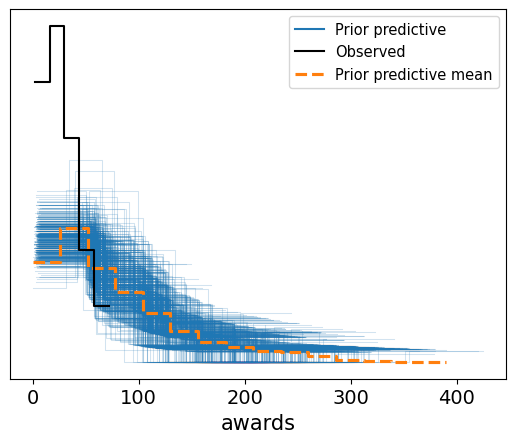

In [10]:
# prior predictive check
ax = az.plot_ppc(prior_predictive, group="prior", observed=True)

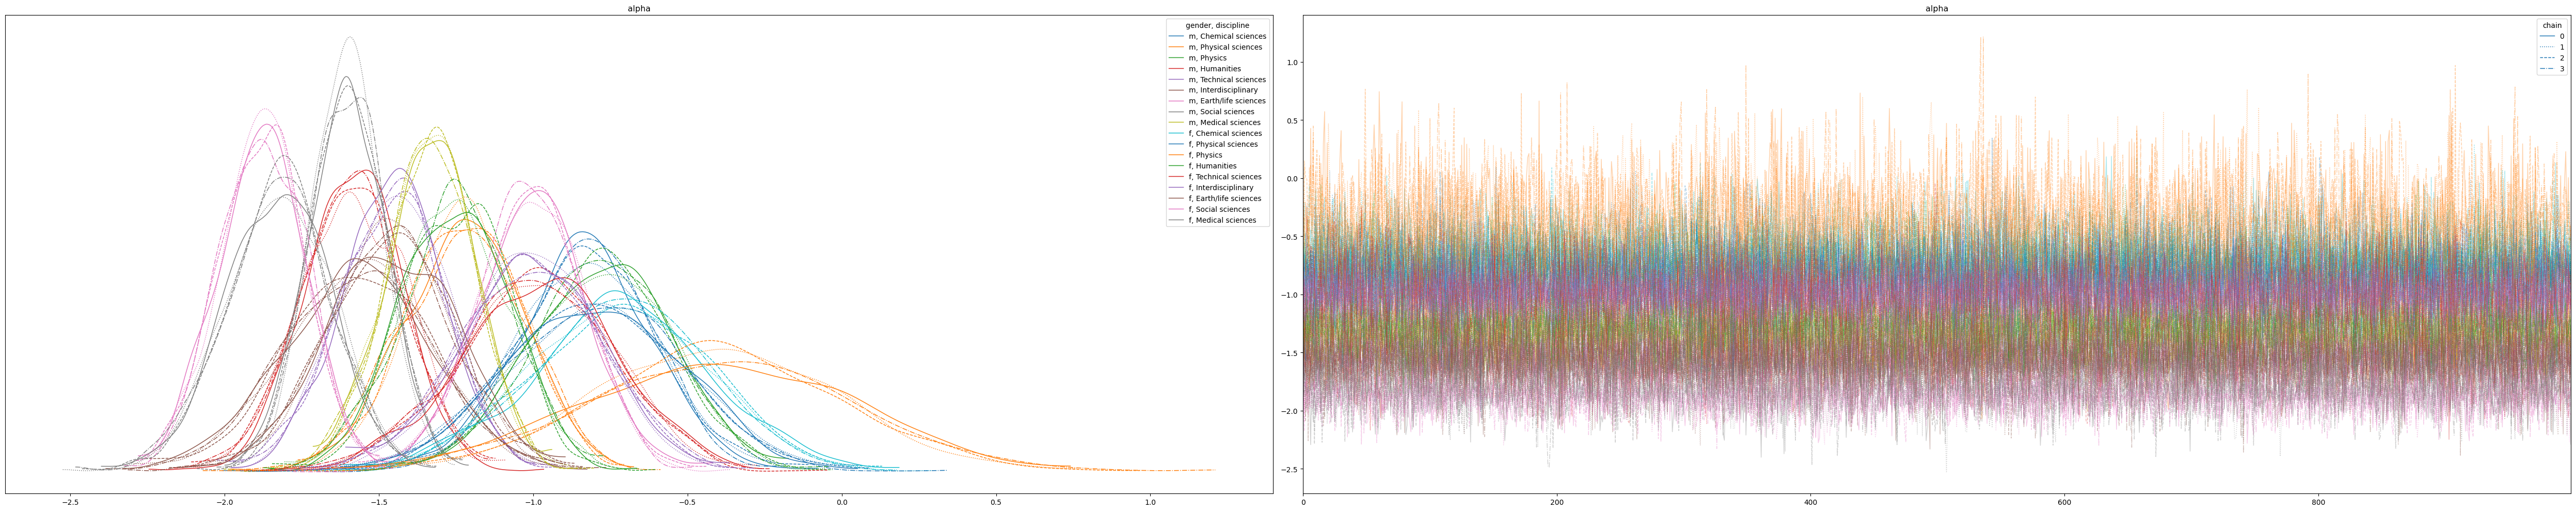

In [8]:
plot_trace(posterior, var_names=["alpha"], legend=True, figsize=(50,10))

In [11]:
az.summary(posterior)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"alpha[m, Chemical sciences]",-0.830,0.220,-1.261,-0.437,0.002,0.004,7948.0,2631.0,1.0
"alpha[m, Physical sciences]",-1.227,0.191,-1.576,-0.864,0.002,0.003,7904.0,2940.0,1.0
"alpha[m, Physics]",-0.785,0.229,-1.215,-0.358,0.003,0.004,8330.0,2937.0,1.0
"alpha[m, Humanities]",-1.588,0.166,-1.895,-1.287,0.002,0.003,9351.0,2820.0,1.0
"alpha[m, Technical sciences]",-1.459,0.169,-1.791,-1.157,0.002,0.003,9004.0,3126.0,1.0
"alpha[m, Interdisciplinary]",-1.571,0.237,-2.024,-1.138,0.002,0.004,9434.0,2744.0,1.0
"alpha[m, Earth/life sciences]",-1.006,0.174,-1.333,-0.686,0.002,0.003,8377.0,2950.0,1.0
"alpha[m, Social sciences]",-1.603,0.123,-1.833,-1.374,0.001,0.002,9072.0,3578.0,1.0
"alpha[m, Medical sciences]",-1.334,0.145,-1.613,-1.067,0.002,0.002,7722.0,3162.0,1.0
"alpha[f, Chemical sciences]",-0.723,0.293,-1.300,-0.200,0.003,0.006,10756.0,2739.0,1.0
